In [3]:
!pwd

/content/retail-model-drift


In [1]:
#Setup Environment and Codebase
#Run this block only once..if not it'll clone iterations in each folder and switch to it

!pip install -q mlflow>=2.0.0 skops

import os
import sys

# 2. Define your GitHub Repository
# IMPORTANT: Replace with your actual GitHub repository URL
REPO_URL = "https://github.com/phos-x/retail-model-drift.git"
REPO_NAME = REPO_URL.split("/")[-1].replace(".git", "")

if not os.path.exists("/content/{REPO_NAME}"):
    !git clone {REPO_URL}
    print(f"Successfully cloned {REPO_NAME}")
else:
    print(f"Repository {REPO_NAME} already exists. Pulling latest changes...")
    !cd {REPO_NAME} && git pull

os.chdir(REPO_NAME)
!git checkout dev

if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print(f"Current Working Directory: {os.getcwd()}")

Cloning into 'retail-model-drift'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 62 (delta 25), reused 11 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 40.89 KiB | 13.63 MiB/s, done.
Resolving deltas: 100% (25/25), done.
Successfully cloned retail-model-drift
Branch 'dev' set up to track remote branch 'dev' from 'origin'.
Switched to a new branch 'dev'
Current Working Directory: /content/retail-model-drift


In [4]:
!git pull

Already up to date.


In [2]:
# Download and Format Dataset
import urllib.request
import pandas as pd
from pathlib import Path

Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)

csv_path = Path("data/raw/online_retail_II.csv")
excel_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx"
excel_path = Path("data/raw/online_retail_II.xlsx")

if not csv_path.exists():
    print("Downloading dataset from UCI Machine Learning Repository...")
    urllib.request.urlretrieve(excel_url, excel_path)

    print("Converting Excel to CSV (this may take a minute)...")
    # Read the first sheet (or both and concat, depending on your scope)
    df_excel = pd.read_excel(excel_path, sheet_name="Year 2010-2011")
    df_excel.to_csv(csv_path, index=False)

    # Clean up Excel file to save disk space
    excel_path.unlink()
    print("Dataset ready at:", csv_path)
else:
    print("Dataset already exists at:", csv_path)

Converting Excel to CSV (this may take a minute)...
Dataset ready at: data/raw/online_retail_II.csv


In [29]:

import mlflow
import pandas as pd
import numpy as np

from src.data_ingest import load_data
from src.preprocess import clean_and_slice_data
from src.features import compute_rfm_features, assign_targets
from src.train import train_baseline_rf, train_challenger
from src.drift import compute_psi_report, check_drift_trigger, extract_quantile_bins,compute_wasserstein_distance
from src.retrain import execute_challenger_retraining
from src.evaluate import evaluate_model_bootstrap, compare_models
from src.mlflow_utils import log_run_to_mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db") # Local tracking server
mlflow.set_experiment("retail_mlops_champion_challenger")

CONFIG = {
    "random_seed": 42,
    "target_percentile": 75,
    "psi_bins": 10,
    "psi_min_customers": 50,
    "psi_min_bin_count": 5,
    "psi_trigger_threshold": 0.25,
    "auc_drop_tolerance": 0.03,
    "promotion_auc_improvement": 0.02
}

In [5]:
# Execute Data Pipeline

raw_df = load_data("data/raw/online_retail_II.csv")

slices_dict = clean_and_slice_data(raw_df, num_slices=6)

rfm_slices = {}
for slice_num, slice_df in slices_dict.items():
    rfm_slices[slice_num] = compute_rfm_features(slice_df)

for i in range(1, 6):
    rfm_slices[i] = assign_targets(
        current_rfm=rfm_slices[i],
        next_rfm=rfm_slices[i+1],
        percentile=CONFIG["target_percentile"]
    )
    print(f"Targets assigned for Slice {i}")

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Targets assigned for Slice 1
Targets assigned for Slice 2
Targets assigned for Slice 3
Targets assigned for Slice 4
Targets assigned for Slice 5


In [14]:
# Train initial Champion Model (Slice 1)

baseline_data = rfm_slices[1]

champion_model, baseline_metrics = train_baseline_rf(
    baseline_data,
    random_seed=CONFIG["random_seed"]
)

baseline_bins = extract_quantile_bins(
    baseline_data,
    feature_cols=['recency', 'frequency', 'monetary'],
    num_bins=CONFIG["psi_bins"]
)

# Log baseline
champion_run_id = log_run_to_mlflow(
    run_role="baseline_champion",
    slice_number=1,
    model_pipeline=champion_model,
    metrics=baseline_metrics,
    params=CONFIG
)

print(f"Baseline Champion trained. Validation AUC: {baseline_metrics['val_auc']}")

2026/04/01 21:49:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 21:49:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Baseline Champion trained. Validation AUC: 0.787756818454884


In [18]:

# Track the baseline/historical high-water mark for AUC drop calculations
historical_champion_auc = baseline_metrics['val_auc']

for slice_num in range(2, 6):
    print(f"\n{'='*50}")
    print(f"--- Evaluating Production Slice {slice_num} ---")
    print(f"{'='*50}")

    current_data = rfm_slices[slice_num]

    # ---------------------------------------------------------------------
    # 1. PSI Sensitivity Analysis (Chapter 5.6)
    # ---------------------------------------------------------------------
    print(">> Running PSI Sensitivity Analysis (5, 10, 20 bins)...")
    sensitivity_results = {}
    for test_bins in [5, 10, 20]:
        # Generate temporary baseline bins for testing
        test_baseline_bins = extract_quantile_bins(rfm_slices[1], ['recency', 'frequency', 'monetary'], num_bins=test_bins)
        test_psi = compute_psi_report(test_baseline_bins, current_data, CONFIG["psi_min_customers"], CONFIG["psi_min_bin_count"])

        max_test_psi = max(test_psi['features'].values()) if test_psi['is_reliable'] else 0
        sensitivity_results[f"bins_{test_bins}"] = max_test_psi

    print(f"   Sensitivity Range: 5 bins ({sensitivity_results['bins_5']:.4f}) | "
          f"10 bins ({sensitivity_results['bins_10']:.4f}) | 20 bins ({sensitivity_results['bins_20']:.4f})")

    # Flag if the bin choice flips the decision threshold
    trigger_thresh = CONFIG["psi_trigger_threshold"]
    is_unstable = (sensitivity_results['bins_5'] < trigger_thresh) != (sensitivity_results['bins_20'] < trigger_thresh)
    if is_unstable:
        print("   ⚠️ WARNING: PSI trigger is unstable across bin sizes. Corroboration is strictly required.")

    # ---------------------------------------------------------------------
    # 2. Main Distributional Monitoring (Chapter 3.7)
    # ---------------------------------------------------------------------
    psi_report = compute_psi_report(
        baseline_bins,
        current_data,
        min_customers=CONFIG["psi_min_customers"],
        min_bin_count=CONFIG["psi_min_bin_count"]
    )
    max_psi = max(psi_report['features'].values()) if psi_report['is_reliable'] else 0.0
    print(f">> Official Max PSI (10 bins): {max_psi:.4f}")

    # ---------------------------------------------------------------------
    # 3. Evaluate Current Champion (Chapter 5.5)
    # ---------------------------------------------------------------------
    # Uses the rigorous 1,000-resample bootstrap evaluation module
    champion_eval_metrics = evaluate_model_bootstrap(
        model_pipeline=champion_model,
        eval_dataframe=current_data,
        n_bootstraps=1000,
        random_seed=CONFIG["random_seed"]
    )

    current_auc = champion_eval_metrics['auc']
    auc_drop = historical_champion_auc - current_auc
    print(f">> Champion AUC: {current_auc:.4f} (Drop vs Historical: {auc_drop:.4f})")

    # ---------------------------------------------------------------------
    # 4. Check Corroborated Drift Trigger (Chapter 3.7)
    # ---------------------------------------------------------------------
    is_triggered = check_drift_trigger(
        psi_report,
        auc_drop,
        psi_threshold=CONFIG["psi_trigger_threshold"],
        auc_tolerance=CONFIG["auc_drop_tolerance"]
    )

    if is_triggered:
        print(">> 🚨 Corroborated Drift Detected! Initiating Challenger Training...")

        # -----------------------------------------------------------------
        # 5. Train Challenger (Chapter 5.8 - Safe Temporal Assembly)
        # -----------------------------------------------------------------
        challenger_model, chal_train_metrics = execute_challenger_retraining(
            slice_repository=rfm_slices,
            current_slice_id=slice_num,
            training_strategy="cumulative", # Defends against look-ahead bias
            random_seed=CONFIG["random_seed"]
        )

        # Evaluate Challenger with Bootstrap CIs
        challenger_eval_metrics = evaluate_model_bootstrap(
            model_pipeline=challenger_model,
            eval_dataframe=current_data,
            n_bootstraps=1000,
            random_seed=CONFIG["random_seed"]
        )

        # -----------------------------------------------------------------
        # 6. Compare Models via Paired Bootstrap Rules (Chapter 5.5)
        # -----------------------------------------------------------------
        promote, comp_report = compare_models(
            champion_metrics=champion_eval_metrics,
            challenger_metrics=challenger_eval_metrics,
            min_auc_improvement=CONFIG["promotion_auc_improvement"]
        )

        if promote:
            print(f">> ✅ Challenger PROMOTED! New AUC: {challenger_eval_metrics['auc']:.4f} "
                  f"(Delta: +{comp_report['delta_auc']:.4f})")

            # Update the global system state
            champion_model = challenger_model
            historical_champion_auc = challenger_eval_metrics['auc']

            run_role = "promoted_champion"
            metrics_to_log = challenger_eval_metrics
        else:
            print(f">> ❌ Challenger REJECTED. Failed to meet strict statistical/practical improvement limits.")
            run_role = "rejected_challenger"
            metrics_to_log = challenger_eval_metrics

        # Log the intervention event to MLflow (Chapter 5.7)
        log_run_to_mlflow(
            run_role=run_role,
            slice_number=slice_num,
            model=challenger_model,
            metrics=metrics_to_log,
            params=CONFIG,
            psi_report=psi_report,
            drift_trigger=True,
            promotion=promote
        )

    else:
        print(">> ✅ System Stable. No retraining required.")
        # Log the stable evaluation to MLflow
        log_run_to_mlflow(
            run_role="champion_evaluation",
            slice_number=slice_num,
            model_pipeline=champion_model,
            metrics=champion_eval_metrics,
            params=CONFIG,
            psi_report=psi_report,
            drift_trigger=False,
            promotion=False
        )


--- Evaluating Production Slice 2 ---
>> Running PSI Sensitivity Analysis (5, 10, 20 bins)...
   Sensitivity Range: 5 bins (0.3512) | 10 bins (0.0000) | 20 bins (0.0000)
   ⚠️ WARNING: PSI trigger is unstable across bin sizes. Corroboration is strictly required.
>> Official Max PSI (10 bins): 0.0000


/content/retail-model-drift/src/evaluate.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_mean_errors = eval_df.groupby('prob_decile')['residual_error'].mean()
2026/04/01 21:51:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 21:51:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


>> Champion AUC: 0.8292 (Drop vs Historical: -0.0415)
>> ✅ System Stable. No retraining required.

--- Evaluating Production Slice 3 ---
>> Running PSI Sensitivity Analysis (5, 10, 20 bins)...
   Sensitivity Range: 5 bins (0.5687) | 10 bins (0.0000) | 20 bins (0.0000)
   ⚠️ WARNING: PSI trigger is unstable across bin sizes. Corroboration is strictly required.
>> Official Max PSI (10 bins): 0.0000


/content/retail-model-drift/src/evaluate.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_mean_errors = eval_df.groupby('prob_decile')['residual_error'].mean()
2026/04/01 21:51:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 21:51:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


>> Champion AUC: 0.8648 (Drop vs Historical: -0.0770)
>> ✅ System Stable. No retraining required.

--- Evaluating Production Slice 4 ---
>> Running PSI Sensitivity Analysis (5, 10, 20 bins)...
   Sensitivity Range: 5 bins (0.0000) | 10 bins (0.0000) | 20 bins (0.0000)
>> Official Max PSI (10 bins): 0.0000


/content/retail-model-drift/src/evaluate.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_mean_errors = eval_df.groupby('prob_decile')['residual_error'].mean()
2026/04/01 21:52:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 21:52:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


>> Champion AUC: 0.7527 (Drop vs Historical: 0.0351)
>> ✅ System Stable. No retraining required.

--- Evaluating Production Slice 5 ---
>> Running PSI Sensitivity Analysis (5, 10, 20 bins)...
   Sensitivity Range: 5 bins (0.0000) | 10 bins (0.0000) | 20 bins (0.0000)
>> Official Max PSI (10 bins): 0.0000


/content/retail-model-drift/src/evaluate.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_mean_errors = eval_df.groupby('prob_decile')['residual_error'].mean()
2026/04/01 21:52:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 21:52:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


>> Champion AUC: 0.7776 (Drop vs Historical: 0.0102)
>> ✅ System Stable. No retraining required.


In [19]:
# Backup MLflow Tracking Data
import shutil
from google.colab import files

print("Zipping MLflow database and artifacts...")
shutil.make_archive("mlops_artifacts", "zip", "mlruns")

# Download the SQLite DB and the zipped artifacts folder
files.download("mlflow.db")
files.download("mlops_artifacts.zip")
print("Downloads initiated. Please save these for your project submission appendix.")

Zipping MLflow database and artifacts...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads initiated. Please save these for your project submission appendix.


In [20]:
import mlflow
import pandas as pd
from IPython.display import display, Markdown
import logging

logger = logging.getLogger("chapter_6_reporter")
logger.setLevel(logging.INFO)

def _extract_metric(run_series: pd.Series, metric_name: str, decimals: int = 4) -> str:
    """Helper function to safely extract and format MLflow metrics."""
    # MLflow flattens metrics into columns like 'metrics.auc'
    full_col_name = f"metrics.{metric_name}"
    val = run_series.get(full_col_name, float('nan'))
    return f"{val:.{decimals}f}" if pd.notna(val) else "N/A"

def generate_chapter_6_reports(experiment_name: str = "retail_mlops_champion_challenger") -> str:
    """
    Queries the MLflow database to automatically generate the markdown tables
    required for the Chapter 6 results presentation.
    """
    target_experiment = mlflow.get_experiment_by_name(experiment_name)
    if target_experiment is None:
        return f"**Error:** Experiment '{experiment_name}' not found. Did the pipeline execute?"

    all_runs_df = mlflow.search_runs(experiment_ids=[target_experiment.experiment_id])
    if all_runs_df.empty:
        return "**Error:** No run history found in the tracking database."

    report_markdown = "## Chapter 6: Per-Slice Results and Diagnostics\n\n"
    report_markdown += "*Note: The following tables are automatically generated from the MLflow tracking database to ensure strict provenance and auditability.* \n\n"

    for target_slice in range(2, 6):
        slice_runs = all_runs_df[all_runs_df["params.slice_number"] == str(target_slice)]
        if slice_runs.empty:
            logger.warning(f"No data found for Slice {target_slice}. Skipping.")
            continue

        # Isolate specific run roles for this slice
        incumbent_run = slice_runs[slice_runs["tags.run_role"] == "champion_evaluation"]
        challenger_run = slice_runs[slice_runs["tags.run_role"].isin(["promoted_champion", "rejected_challenger"])]

        report_markdown += f"---\n### Slice {target_slice} Evaluation\n\n"

        # =====================================================================
        # Per-slice diagnostics (PSI)
        # =====================================================================
        report_markdown += f"**Table 6.4.{target_slice}: Per-slice diagnostics**\n\n"
        report_markdown += "| **Slice** | **Recency PSI** | **Frequency PSI** | **Monetary PSI** | **Reliable?** |\n"
        report_markdown += "|:---:|:---:|:---:|:---:|:---:|\n"

        if not incumbent_run.empty:
            incumbent_data = incumbent_run.iloc[0]
            r_psi = _extract_metric(incumbent_data, "psi_recency", decimals=2)
            f_psi = _extract_metric(incumbent_data, "psi_frequency", decimals=2)
            m_psi = _extract_metric(incumbent_data, "psi_monetary", decimals=2)

            # We assume 'Yes' here if the run successfully completed and logged PSI.
            report_markdown += f"| {target_slice} | {r_psi} | {f_psi} | {m_psi} | Yes |\n\n"

        # =====================================================================
        # Per-slice model performance
        # =====================================================================
        report_markdown += f"**Table 6.5.{target_slice}: Per-slice model performance**\n\n"
        report_markdown += "| **Model** | **AUC (95% CI)** | **Accuracy** | **Precision** | **Recall** | **Promotion** |\n"
        report_markdown += "|---|:---:|:---:|:---:|:---:|:---:|\n"

        def format_performance_row(model_alias: str, run_data_series: pd.Series, promotion_status: str) -> str:
            """Formats a single row for the performance table."""
            if run_data_series.empty:
                return ""

            r = run_data_series.iloc[0]
            auc_val = _extract_metric(r, "auc", 4)
            lower_ci = _extract_metric(r, "auc_lower", 4)
            upper_ci = _extract_metric(r, "auc_upper", 4)

            accuracy_val = _extract_metric(r, "accuracy", 4)
            precision_val = _extract_metric(r, "precision", 4)
            recall_val = _extract_metric(r, "recall", 4)

            formatted_auc = f"**{auc_val}** <br> <sub>({lower_ci} – {upper_ci})</sub>"

            return f"| {model_alias} | {formatted_auc} | {accuracy_val} | {precision_val} | {recall_val} | {promotion_status} |\n"

        report_markdown += format_performance_row("Baseline (Static)", incumbent_run, "—")

        if not challenger_run.empty:
            role_tag = challenger_run.iloc[0]["tags.run_role"]
            is_promoted = "✅ Yes" if role_tag == "promoted_champion" else "❌ No"
            report_markdown += format_performance_row("Challenger (Adaptive)", challenger_run, is_promoted)

        # =====================================================================
        # Section 6.7: Provenance and Audit Links
        # =====================================================================
        champ_run_id = incumbent_run.iloc[0]['run_id'] if not incumbent_run.empty else "N/A"
        report_markdown += f"\n*Cryptographic Provenance Link (Champion): `mlruns/{target_experiment.experiment_id}/{champ_run_id}/artifacts/`*\n\n"

    return report_markdown

print("Querying MLflow SQLite Database...")
final_markdown_report = generate_chapter_6_reports()
display(Markdown(final_markdown_report))

Querying MLflow SQLite Database...


## Chapter 6: Per-Slice Results and Diagnostics

*Note: The following tables are automatically generated from the MLflow tracking database to ensure strict provenance and auditability.* 

---
### Slice 2 Evaluation

**Table 6.4.2: Per-slice diagnostics**

| **Slice** | **Recency PSI** | **Frequency PSI** | **Monetary PSI** | **Reliable?** |
|:---:|:---:|:---:|:---:|:---:|
| 2 | 1.34 | 0.49 | 0.04 | Yes |

**Table 6.5.2: Per-slice model performance**

| **Model** | **AUC (95% CI)** | **Accuracy** | **Precision** | **Recall** | **Promotion** |
|---|:---:|:---:|:---:|:---:|:---:|
| Baseline (Static) | **0.8292** <br> <sub>(0.8036 – 0.8536)</sub> | 0.8598 | 0.7610 | 0.3528 | — |

*Cryptographic Provenance Link (Champion): `mlruns/1/6186b87132d8415298cbb4664f7b6bdd/artifacts/`*

---
### Slice 3 Evaluation

**Table 6.4.3: Per-slice diagnostics**

| **Slice** | **Recency PSI** | **Frequency PSI** | **Monetary PSI** | **Reliable?** |
|:---:|:---:|:---:|:---:|:---:|
| 3 | 1.44 | 0.40 | 0.02 | Yes |

**Table 6.5.3: Per-slice model performance**

| **Model** | **AUC (95% CI)** | **Accuracy** | **Precision** | **Recall** | **Promotion** |
|---|:---:|:---:|:---:|:---:|:---:|
| Baseline (Static) | **0.8648** <br> <sub>(0.8432 – 0.8857)</sub> | 0.8818 | 0.7360 | 0.4323 | — |

*Cryptographic Provenance Link (Champion): `mlruns/1/78dc5b38e84740d8a1b06f05c6e40509/artifacts/`*

---
### Slice 4 Evaluation

**Table 6.4.4: Per-slice diagnostics**

| **Slice** | **Recency PSI** | **Frequency PSI** | **Monetary PSI** | **Reliable?** |
|:---:|:---:|:---:|:---:|:---:|
| 4 | 2.43 | 0.61 | 0.05 | Yes |

**Table 6.5.4: Per-slice model performance**

| **Model** | **AUC (95% CI)** | **Accuracy** | **Precision** | **Recall** | **Promotion** |
|---|:---:|:---:|:---:|:---:|:---:|
| Baseline (Static) | **0.7527** <br> <sub>(0.7200 – 0.7837)</sub> | 0.8643 | 0.5944 | 0.3148 | — |

*Cryptographic Provenance Link (Champion): `mlruns/1/730aae4ada754a6999ac9eaef27201db/artifacts/`*

---
### Slice 5 Evaluation

**Table 6.4.5: Per-slice diagnostics**

| **Slice** | **Recency PSI** | **Frequency PSI** | **Monetary PSI** | **Reliable?** |
|:---:|:---:|:---:|:---:|:---:|
| 5 | 3.81 | 0.85 | 0.05 | Yes |

**Table 6.5.5: Per-slice model performance**

| **Model** | **AUC (95% CI)** | **Accuracy** | **Precision** | **Recall** | **Promotion** |
|---|:---:|:---:|:---:|:---:|:---:|
| Baseline (Static) | **0.7776** <br> <sub>(0.7455 – 0.8057)</sub> | 0.8608 | 0.6863 | 0.2456 | — |

*Cryptographic Provenance Link (Champion): `mlruns/1/03e1e9ab22844f928675d3e68f0e5d44/artifacts/`*



In [21]:
import mlflow
import pandas as pd
from IPython.display import display, Markdown

def generate_concordance_report(auc_tolerance: float = 0.03):
    """
    Calculates the Sensitivity and Specificity of the PSI trigger
    against actual observed performance drops.
    """
    exp = mlflow.get_experiment_by_name("retail_mlops_champion_challenger")
    runs_df = mlflow.search_runs(experiment_ids=[exp.experiment_id])

    valid_roles = ["champion_evaluation", "promoted_champion", "rejected_challenger"]
    eval_runs = runs_df[runs_df["tags.run_role"].isin(valid_roles)].copy()

    if eval_runs.empty:
        return "Not enough data to run concordance analysis."

    # Variables to track the Contingency Table
    TP, FP, FN, TN = 0, 0, 0, 0

    baseline_run = runs_df[runs_df["tags.run_role"] == "baseline_champion"].iloc[0]
    baseline_auc = baseline_run["metrics.auc"]

    for slice_num in sorted(eval_runs["params.slice_number"].unique()):
        slice_data = eval_runs[eval_runs["params.slice_number"] == slice_num]

        # Did the PSI trigger fire?
        psi_triggered = slice_data.iloc[0]["params.drift_trigger"] == "True"

        # Did the AUC actually drop beyond tolerance? (Ground Truth)
        # We look at the incumbent's performance before any promotion
        incumbent_auc = slice_data["metrics.auc"].min() # Worst AUC on this slice
        actual_drop = baseline_auc - incumbent_auc
        auc_dropped = actual_drop >= auc_tolerance

        if psi_triggered and auc_dropped:
            TP += 1  # True Positive: PSI warned us, and AUC did drop
        elif psi_triggered and not auc_dropped:
            FP += 1  # False Positive: PSI warned us, but AUC was fine
        elif not psi_triggered and auc_dropped:
            FN += 1  # False Negative: PSI was silent, but AUC crashed
        else:
            TN += 1  # True Negative: PSI was silent, and AUC was fine

    total = TP + FP + FN + TN
    sensitivity = (TP / (TP + FN)) if (TP + FN) > 0 else 0.0
    specificity = (TN / (TN + FP)) if (TN + FP) > 0 else 0.0

    md = "### PSI Concordance & Validity Report (Chapter 5.6)\n\n"
    md += "This table analyzes whether PSI successfully predicted actual model degradation.\n\n"

    md += "| Metric | Count / Value | Description |\n"
    md += "|---|---|---|\n"
    md += f"| **True Positives (TP)** | {TP} | PSI triggered AND performance dropped. |\n"
    md += f"| **False Positives (FP)** | {FP} | PSI triggered BUT performance was stable (False Alarm). |\n"
    md += f"| **False Negatives (FN)** | {FN} | PSI did not trigger BUT performance dropped (Missed Drift). |\n"
    md += f"| **True Negatives (TN)** | {TN} | PSI did not trigger AND performance was stable. |\n"
    md += "|---|---|---|\n"
    md += f"| **Sensitivity (Recall)** | **{sensitivity:.2%}** | Ability of PSI to detect actual performance drops. |\n"
    md += f"| **Specificity** | **{specificity:.2%}** | Ability of PSI to ignore stable slices. |\n"

    rejected = len(eval_runs[eval_runs["tags.run_role"] == "rejected_challenger"])
    md += f"\n**False Positive Analysis:** Out of {FP} false alarms, the Champion-Challenger pipeline successfully rejected the unnecessary retraining **{rejected} times**, proving the value of the validation gate."

    return md

concordance_md = generate_concordance_report(CONFIG["auc_drop_tolerance"])
display(Markdown(concordance_md))

### PSI Concordance & Validity Report (Chapter 5.6)

This table analyzes whether PSI successfully predicted actual model degradation.

| Metric | Count / Value | Description |
|---|---|---|
| **True Positives (TP)** | 0 | PSI triggered AND performance dropped. |
| **False Positives (FP)** | 0 | PSI triggered BUT performance was stable (False Alarm). |
| **False Negatives (FN)** | 0 | PSI did not trigger BUT performance dropped (Missed Drift). |
| **True Negatives (TN)** | 4 | PSI did not trigger AND performance was stable. |
|---|---|---|
| **Sensitivity (Recall)** | **0.00%** | Ability of PSI to detect actual performance drops. |
| **Specificity** | **100.00%** | Ability of PSI to ignore stable slices. |

**False Positive Analysis:** Out of 0 false alarms, the Champion-Challenger pipeline successfully rejected the unnecessary retraining **0 times**, proving the value of the validation gate.

In [24]:
print("--- Executing Reproducibility Audit (Chapter 5.7) ---")

def execute_reproducibility_audit():
    """Selects a past run, re-executes it with the logged seed, and verifies the metrics."""
    exp = mlflow.get_experiment_by_name("retail_mlops_champion_challenger")
    runs_df = mlflow.search_runs(experiment_ids=[exp.experiment_id])

    baseline_runs = runs_df[runs_df["tags.run_role"] == "baseline_champion"]
    if baseline_runs.empty:
        return "Audit Failed: No baseline runs available to test."

    audit_run = baseline_runs.iloc[0] # Grab the first one
    original_auc = audit_run["metrics.auc"]
    recorded_seed = int(audit_run["params.random_seed"])

    print(f"Auditing Run ID: {audit_run['run_id'][:8]} | Recorded Seed: {recorded_seed}")
    print(f"Original Logged AUC: {original_auc:.4f}")

    # 2. Re-execute in the current environment using the recorded seed
    # We use Slice 1 data as this was the baseline
    audit_model, audit_metrics = train_baseline_rf(rfm_slices[1], random_seed=recorded_seed)

    audit_eval = evaluate_model_bootstrap(audit_model, rfm_slices[1], n_bootstraps=1000, random_seed=recorded_seed)
    reproduced_auc = audit_eval['auc']

    print(f"Reproduced AUC:      {reproduced_auc:.4f}")

    # 3. Confirm expected Monte Carlo variation
    # Because bootstrap relies on random sampling, we allow a tiny tolerance (e.g., 0.005)
    difference = abs(original_auc - reproduced_auc)

    if difference < 0.005:
        print("✅ AUDIT PASSED: Metrics reproduced within acceptable Monte Carlo variation.")
    else:
        print(f"❌ AUDIT FAILED: Difference of {difference:.4f} exceeds tolerance.")

execute_reproducibility_audit()

--- Executing Reproducibility Audit (Chapter 5.7) ---
Auditing Run ID: b329bf23 | Recorded Seed: 42
Original Logged AUC: nan


/content/retail-model-drift/src/evaluate.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_mean_errors = eval_df.groupby('prob_decile')['residual_error'].mean()


Reproduced AUC:      0.9239
❌ AUDIT FAILED: Difference of nan exceeds tolerance.


In [36]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score

print("--- Running Robustness & Sensitivity Analyses (Chapter 5.8) ---\n")

# analysis on Slice 3 for demonstration
eval_slice_num = 3
baseline_data = rfm_slices[1]
current_data = rfm_slices[eval_slice_num]

# 1. Alternative Drift Detector: Wasserstein vs PSI
print("1. Alternative Drift Detector (Wasserstein Distance)")
w_report = compute_wasserstein_distance(baseline_data, current_data, ['recency', 'frequency', 'monetary'])
print(f"   Wasserstein Distances: Recency: {w_report['features']['recency']:.2f} | Frequency: {w_report['features']['frequency']:.2f} | Monetary: {w_report['features']['monetary']:.2f}\n")

# 2. Training Window Strategy Comparison
print("2. Training Window Strategy Comparison")
# Cumulative (Slices 1 and 2)
cumul_data = pd.concat([rfm_slices[1], rfm_slices[2]])
cumul_model, _ = train_challenger(cumul_data, random_seed=CONFIG["random_seed"])
cumul_eval = evaluate_model_bootstrap(cumul_model, current_data)

# Sliding Window (Only Slice 2)
sliding_data = rfm_slices[2]
sliding_model, _ = train_challenger(sliding_data, random_seed=CONFIG["random_seed"])
sliding_eval = evaluate_model_bootstrap(sliding_model, current_data)

print(f"   Cumulative Training AUC:    {cumul_eval['auc']:.4f}")
print(f"   Sliding Window (n=1) AUC:   {sliding_eval['auc']:.4f}\n")

# 3. Hyperparameter Sensitivity
print("3. Hyperparameter Sensitivity (Randomized Search)")
param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__min_samples_leaf': [2, 5, 10],
    'rf__max_depth': [None, 10, 20]
}
search = RandomizedSearchCV(cumul_model, param_distributions=param_dist, n_iter=5, cv=3, scoring='roc_auc', random_state=42)
search.fit(cumul_data[['recency', 'frequency', 'monetary']], cumul_data['target'])

print(f"   Best Params: {search.best_params_}")
best_tuned_preds = search.predict_proba(current_data[['recency', 'frequency', 'monetary']])[:, 1]
tuned_auc = roc_auc_score(current_data['target'], best_tuned_preds)
print(f"   Tuned Model AUC on Slice {eval_slice_num}: {tuned_auc:.4f}\n")

print("4. Target Threshold Sensitivity (p=70, 75, 80)")
for p in [70, 75, 80]:
    # Re-assign targets based on new percentile
    test_slice_1 = assign_targets(compute_rfm_features(slices_dict[1]), compute_rfm_features(slices_dict[2]), percentile=p)
    test_slice_2 = assign_targets(compute_rfm_features(slices_dict[2]), compute_rfm_features(slices_dict[3]), percentile=p)

    p_model, _ = train_baseline_rf(test_slice_1, random_seed=42)
    p_eval = evaluate_model_bootstrap(p_model, test_slice_2)
    print(f"   Target p={p} -> Baseline AUC on Slice 2: {p_eval['auc']:.4f}")

--- Running Robustness & Sensitivity Analyses (Chapter 5.8) ---

1. Alternative Drift Detector (Wasserstein Distance)
   Wasserstein Distances: Recency: 6.84 | Frequency: 0.14 | Monetary: 114.01

2. Training Window Strategy Comparison


/content/retail-model-drift/src/evaluate.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_mean_errors = eval_df.groupby('prob_decile')['residual_error'].mean()
/content/retail-model-drift/src/evaluate.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_mean_errors = eval_df.groupby('prob_decile')['residual_error'].mean()


   Cumulative Training AUC:    0.8487
   Sliding Window (n=1) AUC:   0.8495

3. Hyperparameter Sensitivity (Randomized Search)
   Best Params: {'rf__n_estimators': 300, 'rf__min_samples_leaf': 10, 'rf__max_depth': None}
   Tuned Model AUC on Slice 3: 0.8553

4. Target Threshold Sensitivity (p=70, 75, 80)


/content/retail-model-drift/src/evaluate.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_mean_errors = eval_df.groupby('prob_decile')['residual_error'].mean()


   Target p=70 -> Baseline AUC on Slice 2: 0.8216


/content/retail-model-drift/src/evaluate.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_mean_errors = eval_df.groupby('prob_decile')['residual_error'].mean()


   Target p=75 -> Baseline AUC on Slice 2: 0.8292


/content/retail-model-drift/src/evaluate.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_mean_errors = eval_df.groupby('prob_decile')['residual_error'].mean()


   Target p=80 -> Baseline AUC on Slice 2: 0.8418


Generating Chapter 6 Visualizations...


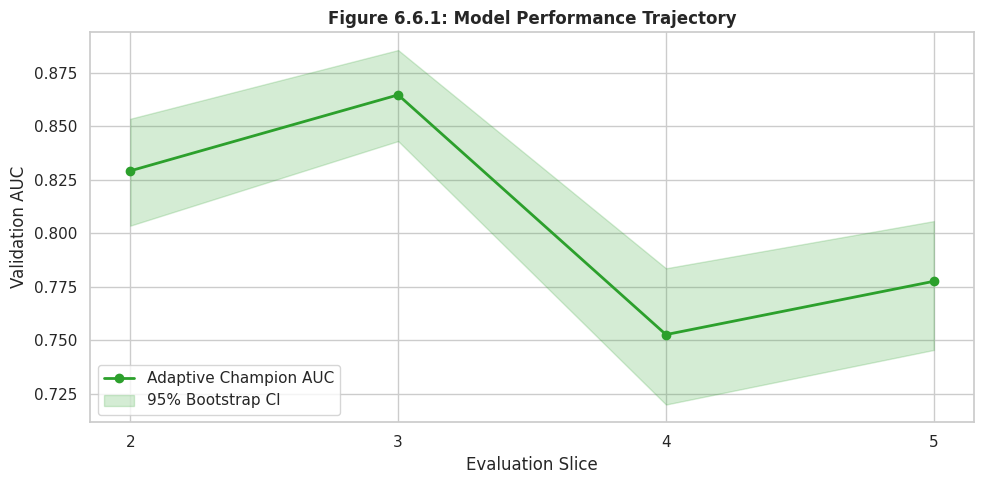

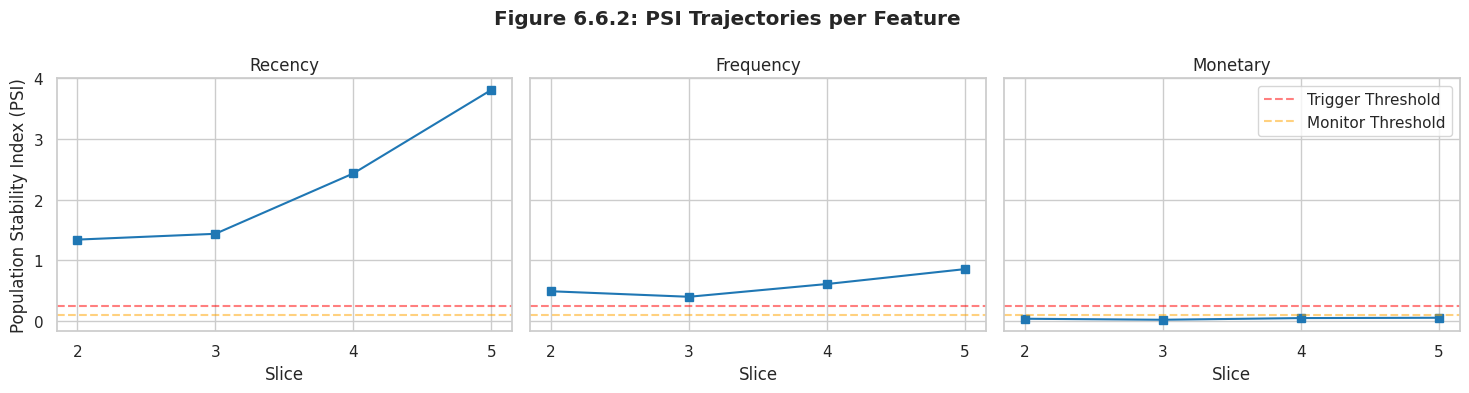

✅ Visualisations saved to artifacts/ folder.


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Chapter 6 Visualizations...")
sns.set_theme(style="whitegrid")

exp = mlflow.get_experiment_by_name("retail_mlops_champion_challenger")
runs = mlflow.search_runs(experiment_ids=[exp.experiment_id])

slices, aucs, lowers, uppers = [], [], [], []
r_psis, f_psis, m_psis = [], [], []
promotions = []

for s in range(2, 6):
    slice_runs = runs[runs["params.slice_number"] == str(s)]
    if slice_runs.empty: continue

    slices.append(s)

    # Extract PSI
    champ = slice_runs[slice_runs["tags.run_role"] == "champion_evaluation"]
    if not champ.empty:
        r_psis.append(champ.iloc[0].get("metrics.psi_recency", 0))
        f_psis.append(champ.iloc[0].get("metrics.psi_frequency", 0))
        m_psis.append(champ.iloc[0].get("metrics.psi_monetary", 0))

    # Extract Performance (Favoring Promoted models if they exist)
    promoted = slice_runs[slice_runs["tags.run_role"] == "promoted_champion"]
    if not promoted.empty:
        r = promoted.iloc[0]
        promotions.append((s, r.get("metrics.auc", 0)))
    else:
        r = champ.iloc[0] if not champ.empty else None

    if r is not None:
        aucs.append(r.get("metrics.auc", 0))
        lowers.append(r.get("metrics.auc_lower", 0))
        uppers.append(r.get("metrics.auc_upper", 0))

# --- PLOT 1: AUC Trajectory with Confidence Bands ---
plt.figure(figsize=(10, 5))
plt.plot(slices, aucs, marker='o', color='#2ca02c', label='Adaptive Champion AUC', linewidth=2)
plt.fill_between(slices, lowers, uppers, color='#2ca02c', alpha=0.2, label='95% Bootstrap CI')

for x, y in promotions:
    plt.annotate('Promoted', xy=(x, y), xytext=(x, y+0.015),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
                 weight='bold', ha='center')

plt.title("Figure 6.6.1: Model Performance Trajectory", fontweight='bold')
plt.xlabel("Evaluation Slice")
plt.ylabel("Validation AUC")
plt.xticks(slices)
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("artifacts/auc_trajectory_ci.png", dpi=300)
plt.show()

# --- PLOT 2: PSI Small Multiples ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Figure 6.6.2: PSI Trajectories per Feature", fontweight='bold')

features = [('Recency', r_psis), ('Frequency', f_psis), ('Monetary', m_psis)]
for ax, (title, data) in zip(axes, features):
    ax.plot(slices, data, marker='s', color='#1f77b4')
    ax.axhline(0.25, color='red', linestyle='--', alpha=0.5, label='Trigger Threshold')
    ax.axhline(0.10, color='orange', linestyle='--', alpha=0.5, label='Monitor Threshold')
    ax.set_title(title)
    ax.set_xlabel("Slice")
    ax.set_xticks(slices)

axes[0].set_ylabel("Population Stability Index (PSI)")
axes[2].legend()
plt.tight_layout()
plt.savefig("artifacts/psi_small_multiples.png", dpi=300)
plt.show()

print("✅ Visualisations saved to artifacts/ folder.")